In [132]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re
import cosinorage as csa

In [ ]:
def recompute_wear_periods(
    input_dir="minute_level",
    output_file="wear_periods_recomputed.csv",
    threshold=0.005,
    min_duration_minutes_nonwear=15,
    min_duration_minutes_wear=30
):
    def detect_non_wear_mask_periods(df, threshold=0.01, min_duration_minutes_nonwear=30):
        """Detect non-wear periods based on low rolling std of x-axis signal."""
        rolling_std = df['x'].rolling('15min').std()
        mask = rolling_std < threshold
        periods = []
        start = None
        for t, is_non in mask.items():
            if is_non and start is None:
                start = t
            elif not is_non and start is not None:
                if (t - start).total_seconds() >= min_duration_minutes_nonwear*60:
                    periods.append((start, t))
                start = None
        # Handle case where non-wear goes to the end
        if start is not None and (df.index[-1] - start).total_seconds() >= min_duration_minutes_nonwear*60:
            periods.append((start, df.index[-1]))
        return periods

    def merge_intervals(intervals):
        """Merge overlapping intervals."""
        if not intervals:
            return []
        intervals = sorted(intervals)
        merged = [list(intervals[0])]
        for s, e in intervals[1:]:
            if s <= merged[-1][1]:
                merged[-1][1] = max(merged[-1][1], e)
            else:
                merged.append([s, e])
        return [(s, e) for s, e in merged]

    def detect_wear_periods(df, threshold=0.1, min_duration_minutes_nonwear=15, min_duration_minutes_wear=30):
        """Wear = complement of non-wear within data window, with minimum wear period duration enforced."""
        nonwears = detect_non_wear_mask_periods(df, threshold, min_duration_minutes_nonwear)
        nonwears = merge_intervals(nonwears)
        if not nonwears:
            return [(df.index.min(), df.index.max())]

        wear_periods = []
        cur_start = df.index.min()
        for s, e in nonwears:
            if s > cur_start:
                wear_periods.append((cur_start, s))
            cur_start = e
        if cur_start < df.index.max():
            wear_periods.append((cur_start, df.index.max()))

        # Enforce minimum wear period duration
        min_wear_seconds = min_duration_minutes_wear * 60
        filtered_wear_periods = [
            (s, e) for s, e in merge_intervals(wear_periods)
            if (e - s).total_seconds() >= min_wear_seconds
        ]
        return filtered_wear_periods

    # === Build new wear_periods dataframe ===
    rows = []
    csv_files = sorted(glob.glob(os.path.join(input_dir, "*.csv")))
    for file_path in csv_files:
        pig_id = os.path.basename(file_path).split(".")[0]
        pig_id = pig_id.replace("_", "-")
        if pig_id.startswith("CO") and not pig_id.startswith("CO-"):
            pig_id = pig_id[:2] + "-" + pig_id[2:]  # normalize CO001 -> CO-001

        df = pd.read_csv(file_path, parse_dates=['timestamp'])
        df = df.set_index('timestamp')

        wear_ints = detect_wear_periods(
            df,
            threshold=threshold,
            min_duration_minutes_nonwear=min_duration_minutes_nonwear,
            min_duration_minutes_wear=min_duration_minutes_wear
        )

        row = {"pig_id": pig_id}
        for i, (s, e) in enumerate(wear_ints, start=1):
            row[f"wear_start_{i}"] = s
            row[f"wear_end_{i}"] = e
        rows.append(row)

    new_wear_df = pd.DataFrame(rows)
    new_wear_df.to_csv(output_file, index=False)
    return new_wear_df

def plot_pig_wear_timeseries(
    wear_df, 
    csv_files, 
    axis='x',
    limit=None
):
    """
    For each pig_id in wear_df, find the corresponding CSV file and plot the x-axis timeseries.
    Wear periods are highlighted in green, and valid wear hours are displayed in the title.
    
    Parameters:
        wear_df (pd.DataFrame): DataFrame containing 'pig_id' and wear_start_/wear_end_ columns
        csv_files (list): List of CSV file paths containing timestamped x-axis data
    """
    for idx, row in wear_df.iterrows():
        if limit is not None and idx >= limit:
            break

        pig_id = row['pig_id']
        # Accept both CO-001.csv and CO_001.csv, case-insensitive
        pig_id_pattern = pig_id.replace("-", "[-_]?")
        pattern = re.compile(rf"{pig_id_pattern}\.csv$", re.IGNORECASE)
        matching_files = [f for f in csv_files if pattern.search(os.path.basename(f))]
        if not matching_files:
            print(f"No file found for pig_id {pig_id}")
            continue
        csv_file = matching_files[0]

        df = pd.read_csv(csv_file)
        ts = pd.to_datetime(df['timestamp'])
        file_label = os.path.basename(csv_file)

        plt.figure(figsize=(12, 2))
        plt.plot(ts, df[f'{axis}'], label=f"{file_label} {axis}")
        plt.axvline(ts.min(), color='g', linestyle='--', label='Min timestamp')
        plt.axvline(ts.max(), color='r', linestyle='--', label='Max timestamp')

        # Plot wear periods as green bands and collect valid wear intervals
        wear_intervals = []
        n_max_wear_periods = (wear_df.shape[1] - 1) // 2

        for i in range(1, n_max_wear_periods + 1):
            start_col = f'wear_start_{i}'
            end_col = f'wear_end_{i}'
            start = row[start_col] if pd.notna(row[start_col]) else ''
            end = row[end_col] if pd.notna(row[end_col]) else ''
            if start and end:
                start_dt = pd.to_datetime(start)
                end_dt = pd.to_datetime(end)
                # Only consider wear periods before the signal ends
                end_dt = min(end_dt, ts.max())
                if start_dt > ts.max():
                    continue
                plt.axvspan(start_dt, end_dt, color='green', alpha=0.2)
                wear_intervals.append((start_dt, end_dt))

        # Calculate valid wear hours
        wear_hours = sum((end - start).total_seconds() / 3600.0 for start, end in wear_intervals)

        # Calculate total hours covered by the timeseries
        total_hours = ((ts.max().floor('h') - ts.min().floor('h')).total_seconds() / 3600.0) if not ts.empty else 0.0

        plt.xlabel('Timestamp')
        plt.ylabel(f'{axis} axis data')
        plt.title(f'{axis} axis data for {file_label} (valid wear hours: {round(wear_hours)}/{round(total_hours)})')
        plt.show()

def save_modified_timeseries(
    wear_df, 
    csv_files, 
    output_dir="minute_level_modified", 
    max_wear_periods=1000
):
    """
    For each pig_id in wear_df, locate the matching timeseries CSV,
    truncate at last wear period or file end, fill non-wear with wear mean,
    save modified data, and plot.

    Parameters
    ----------
    wear_df : pd.DataFrame
        DataFrame with pig_id and wear_start_/wear_end_ columns
    csv_files : list
        List of candidate CSV files containing timestamped x,y,z data
    output_dir : str
        Directory where modified CSVs will be saved
    max_wear_periods : int
        Maximum number of wear_start_/wear_end_ columns to check
    """
    os.makedirs(output_dir, exist_ok=True)

    for idx, row in wear_df.iterrows():
        pig_id = row['pig_id']
        # Accept both CO-001.csv and CO_001.csv, case-insensitive
        pig_id_pattern = pig_id.replace("-", "[-_]?")
        pattern = re.compile(rf"{pig_id_pattern}\.csv$", re.IGNORECASE)
        matching_files = [f for f in csv_files if pattern.search(os.path.basename(f))]
        if not matching_files:
            print(f"No file found for pig_id {pig_id}")
            continue
        csv_file = matching_files[0]

        df = pd.read_csv(csv_file)
        ts = pd.to_datetime(df['timestamp'])
        file_label = os.path.basename(csv_file)

        # Build wear mask
        wear_mask = pd.Series(False, index=df.index)
        wear_periods = []
        last_wear_end = None
        
        max_wear_periods = wear_df.shape[1] // 2

        for i in range(1, max_wear_periods + 1):
            start_col, end_col = f'wear_start_{i}', f'wear_end_{i}'
            start = row[start_col] if start_col in row and pd.notna(row[start_col]) else None
            end = row[end_col] if end_col in row and pd.notna(row[end_col]) else None
            if start is not None and end is not None:
                start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
                mask = (ts >= start_dt) & (ts <= end_dt)
                wear_mask = wear_mask | mask
                wear_periods.append((start_dt, end_dt))
                if last_wear_end is None or end_dt > last_wear_end:
                    last_wear_end = end_dt

        # Truncate at cutoff
        cutoff = min(last_wear_end, ts.max()) if last_wear_end is not None else ts.max()
        valid_mask = ts <= cutoff
        ts_valid = ts[valid_mask]
        df_valid = df.loc[valid_mask].copy()
        wear_mask_valid = wear_mask[valid_mask]

        # Compute average during wear
        wear_mean = df_valid.loc[wear_mask_valid, 'x'].mean() if wear_mask_valid.any() else df_valid['x'].mean()

        # Fill non-wear with wear mean
        df_filled = df_valid.copy()
        df_filled.loc[~wear_mask_valid, 'x'] = wear_mean

        # Save to CSV
        cols_to_save = [c for c in ['timestamp', 'x', 'y', 'z'] if c in df_filled.columns]
        output_path = os.path.join(output_dir, file_label)
        df_filled[cols_to_save].to_csv(output_path, index=False)

In [134]:
# recompute wear periods
recompute_wear_periods()

# load wear periods, clean up column names and strip whitespace from all string cells in the dataframe
wear_df = pd.read_csv("wear_periods_recomputed.csv")
wear_df.columns = [c.strip() for c in wear_df.columns]
wear_df = wear_df.map(lambda x: x.strip() if isinstance(x, str) else x)

# get all CSV files in the minute_level directory and sort them lexicographically by filename
csv_files = sorted(glob.glob("minute_level/*.csv"))

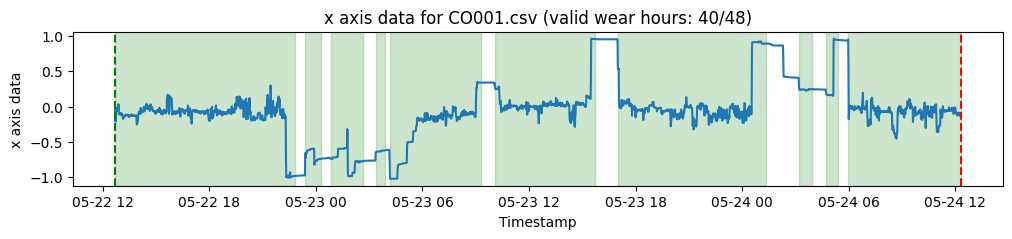

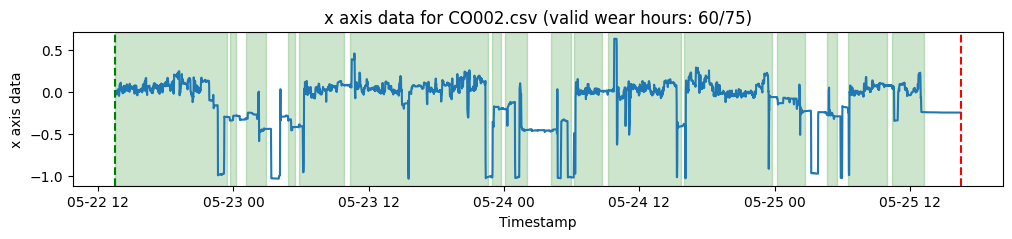

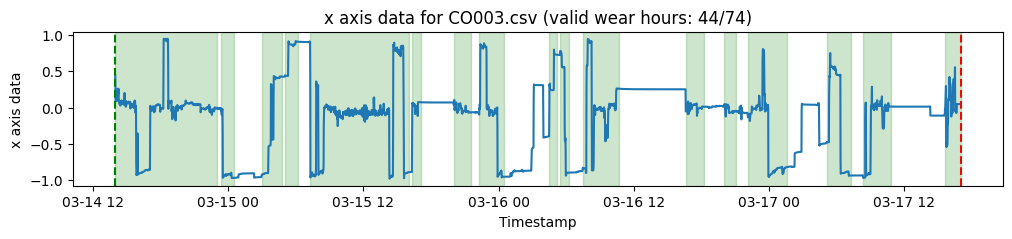

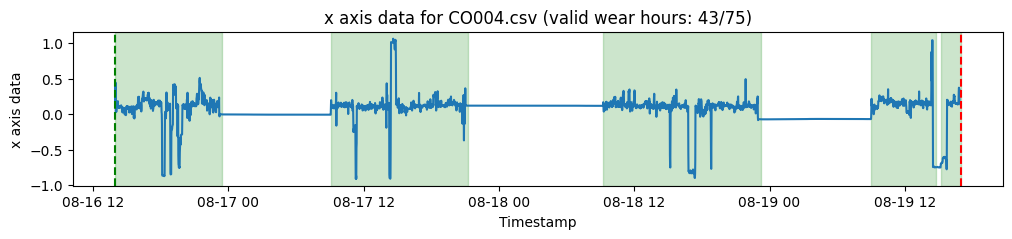

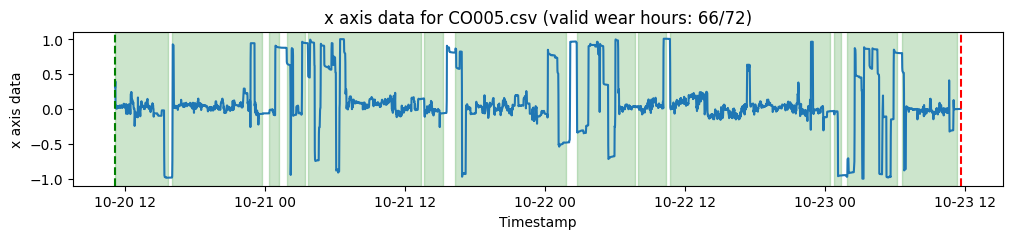

In [135]:
plot_pig_wear_timeseries(wear_df, csv_files, limit=5, axis='x')

In [ ]:
save_modified_timeseries(wear_df, csv_files)

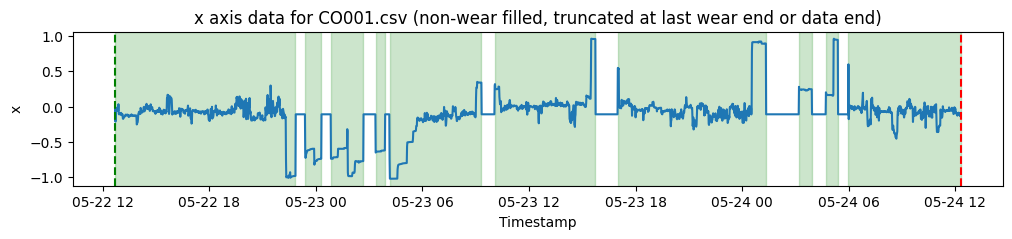

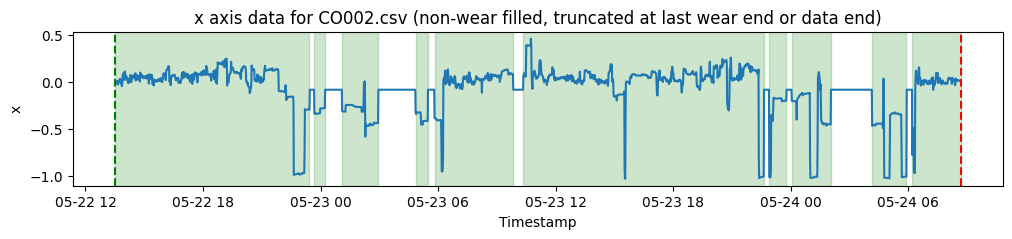

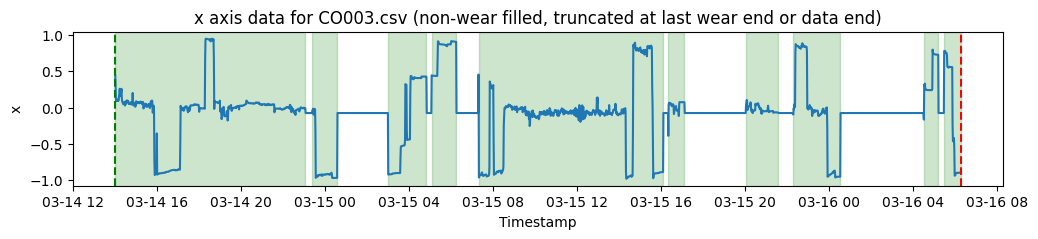

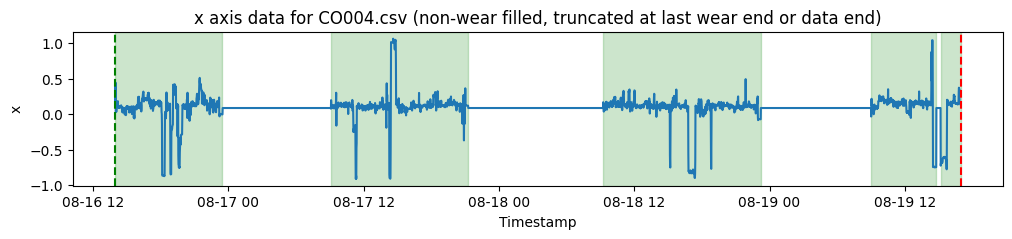

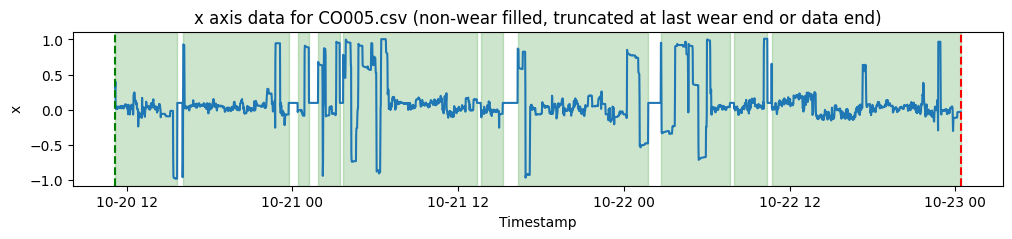

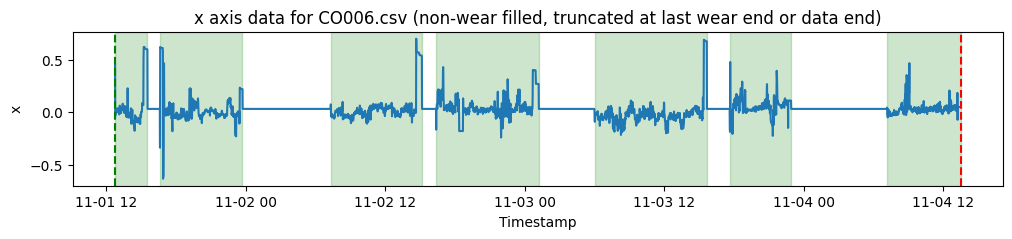

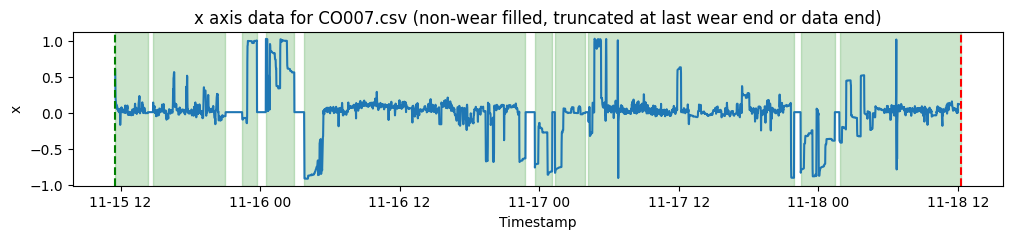

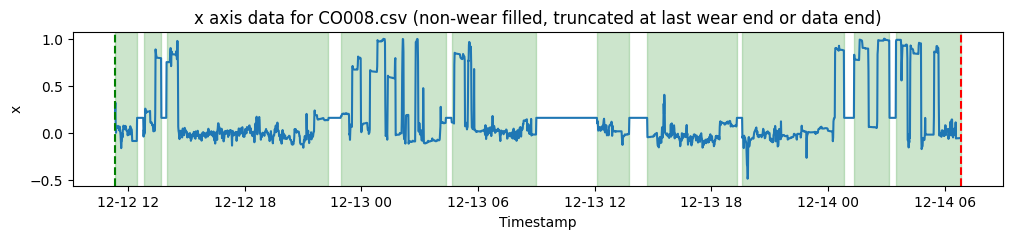

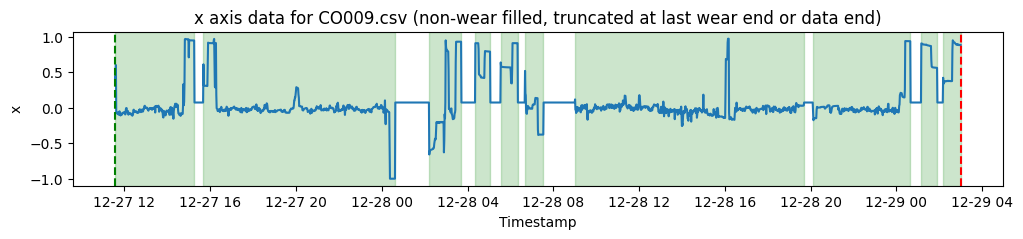

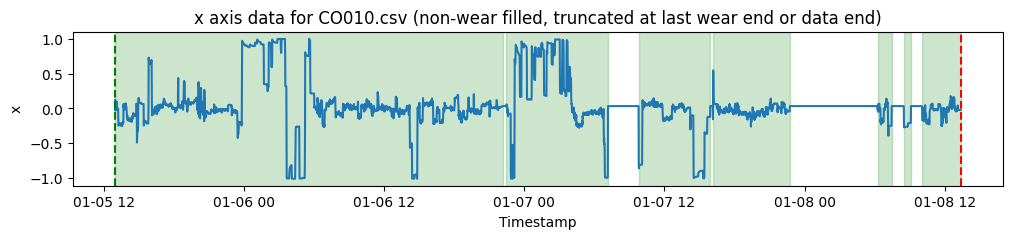

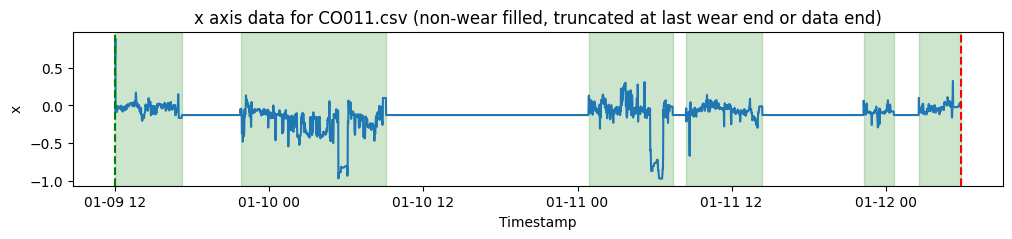

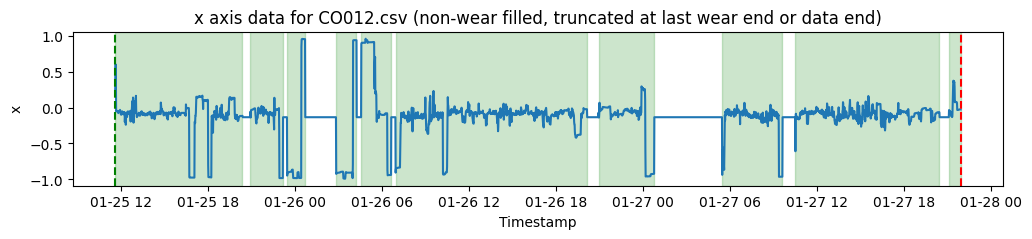

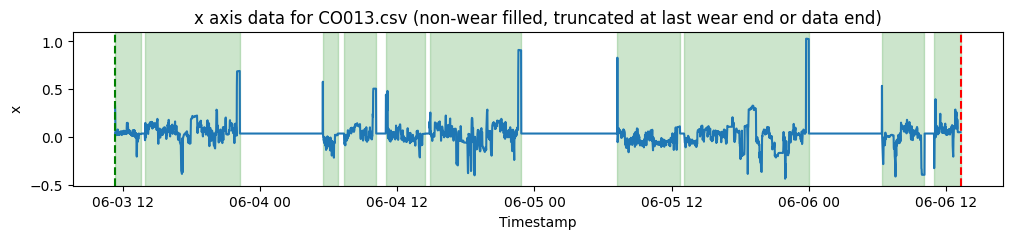

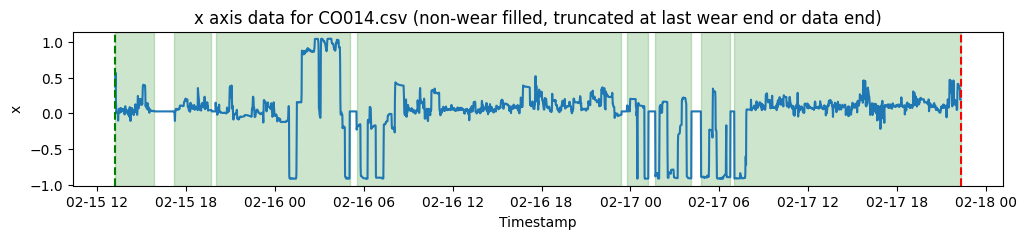

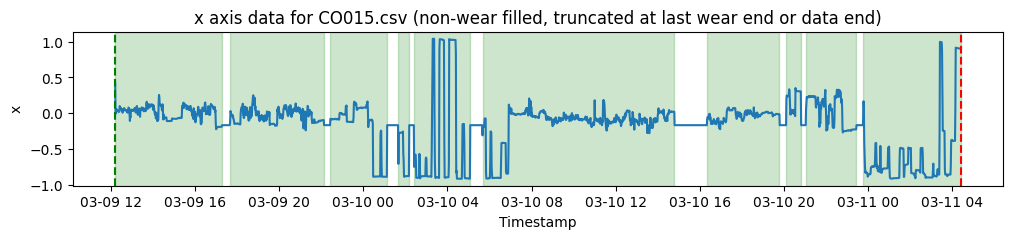

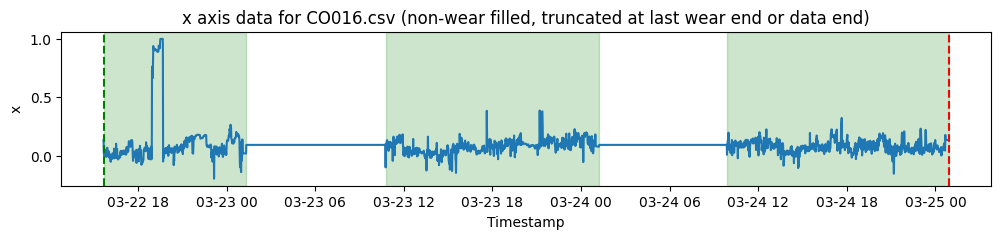

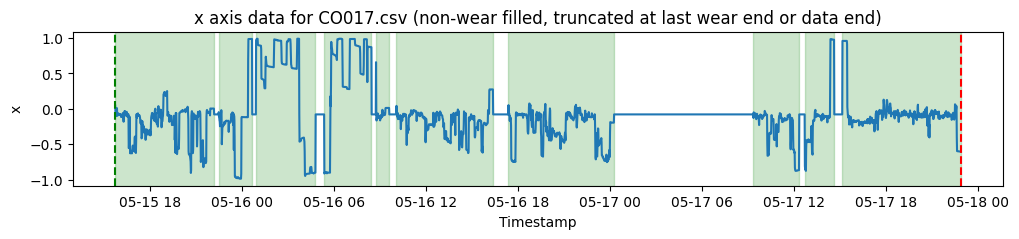

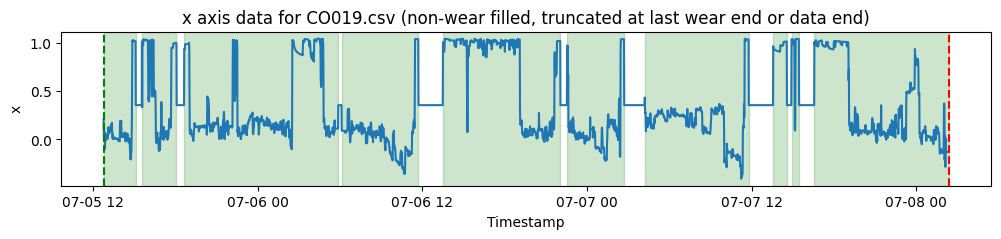

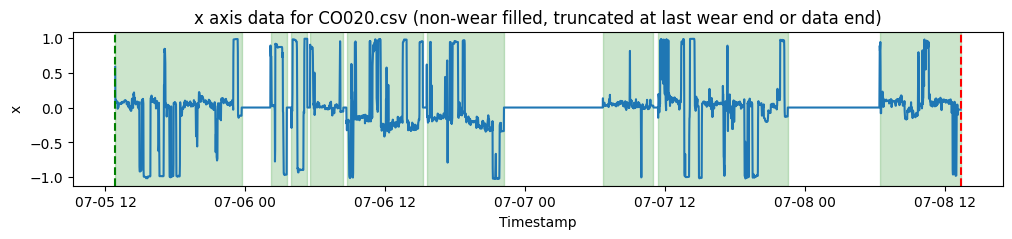

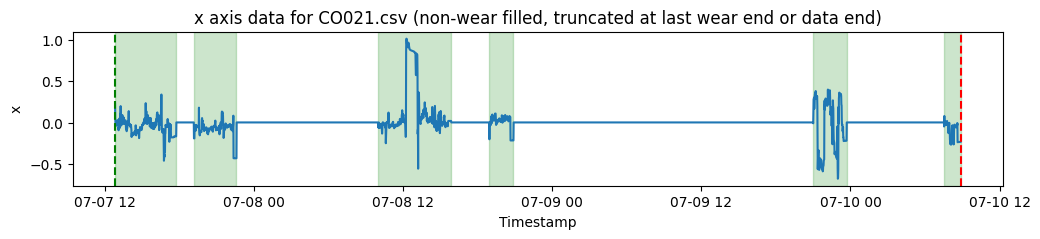

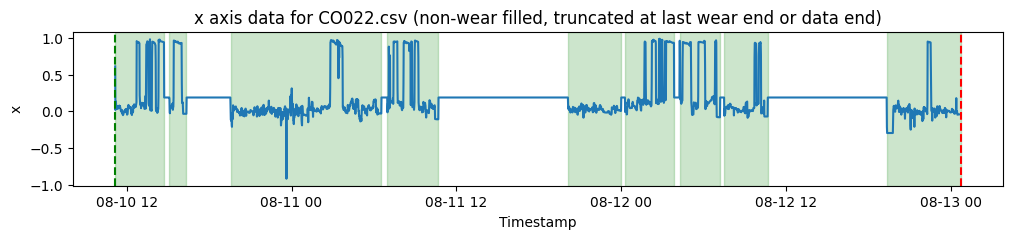

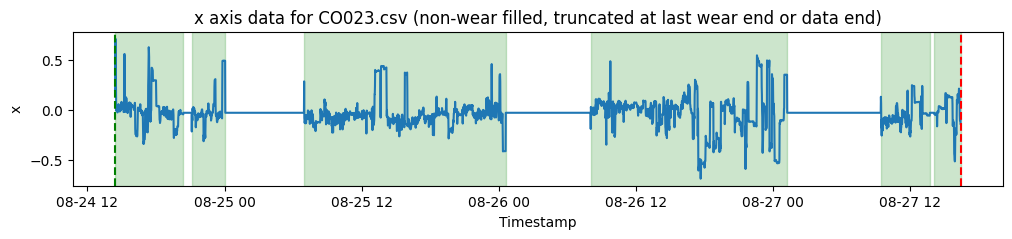

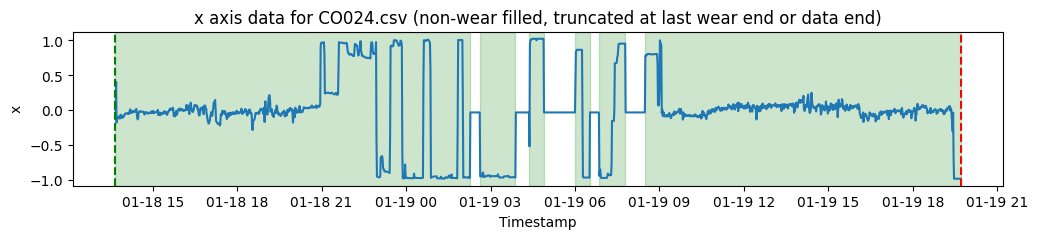

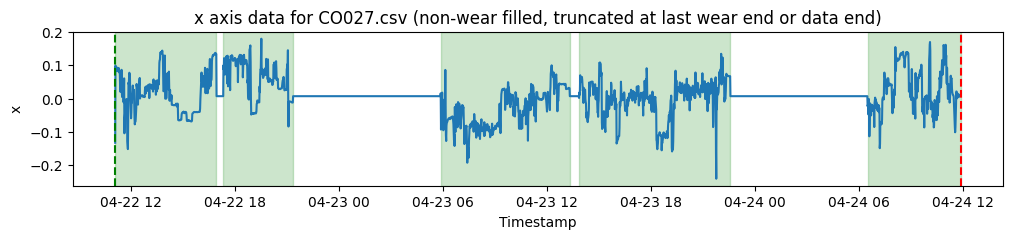

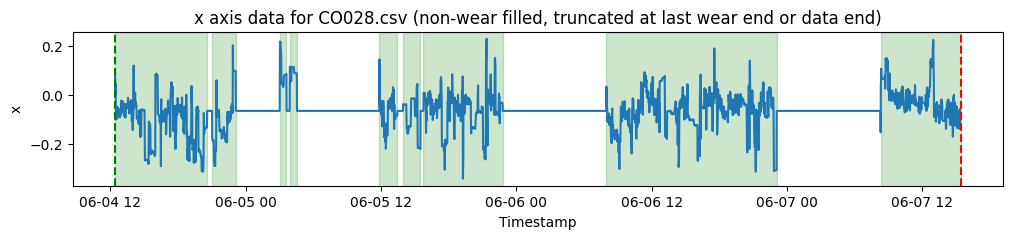

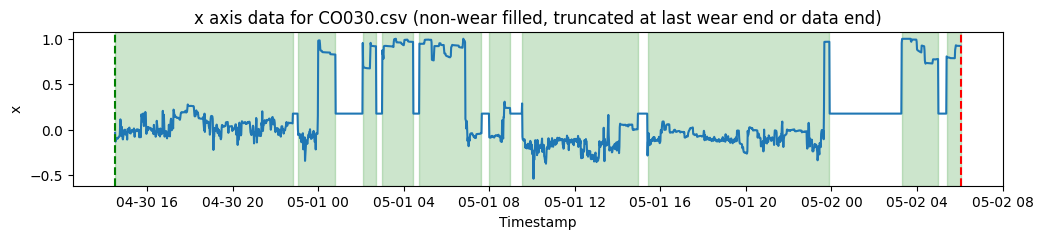

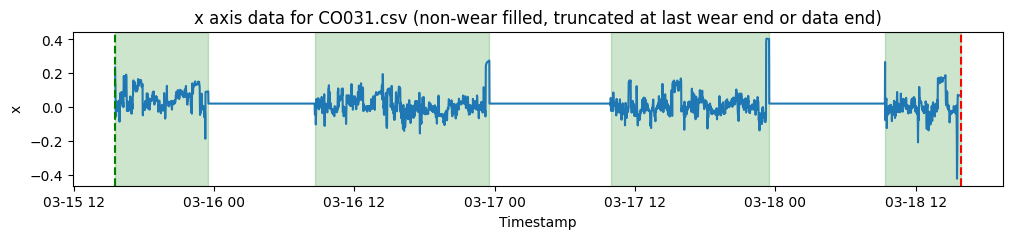

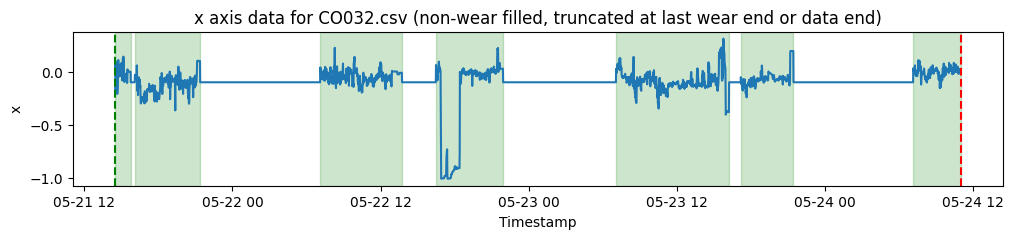

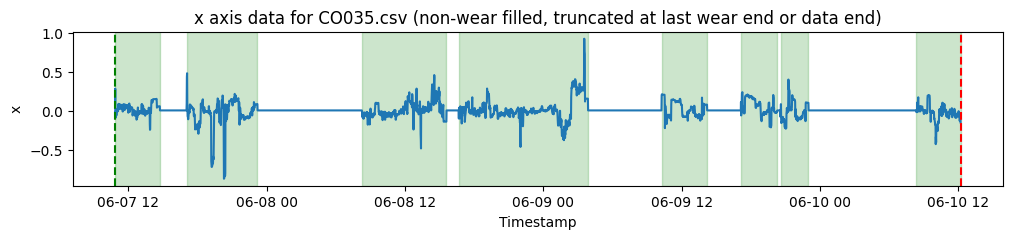

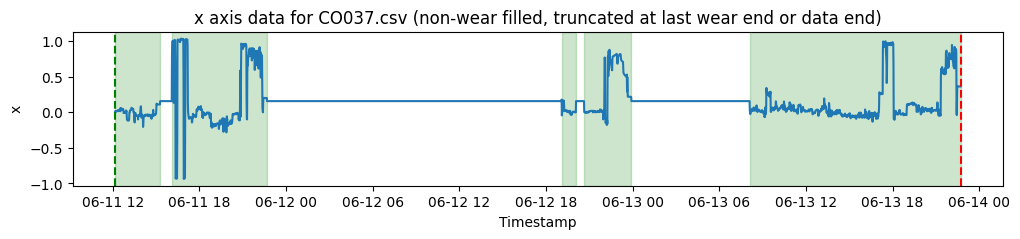

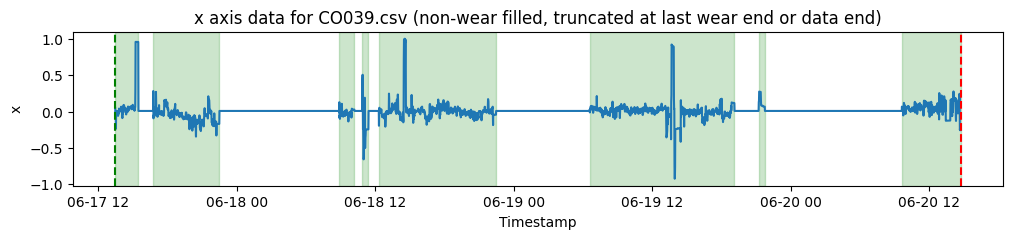

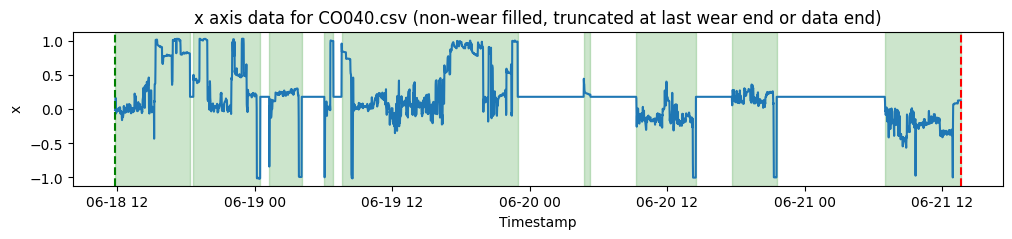

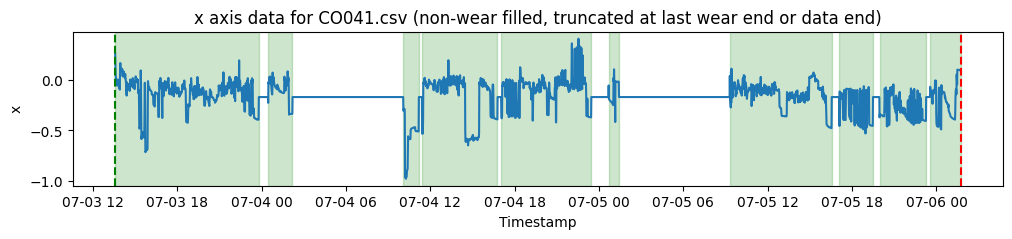

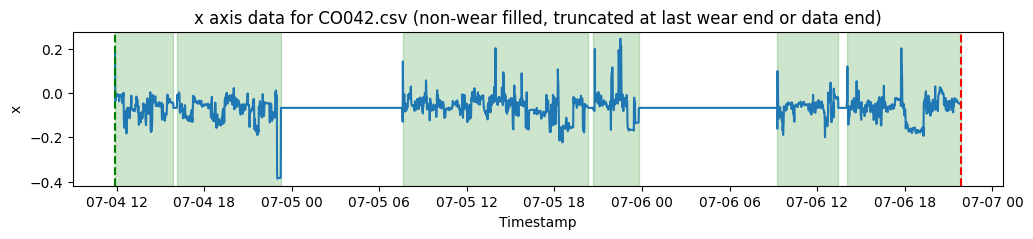

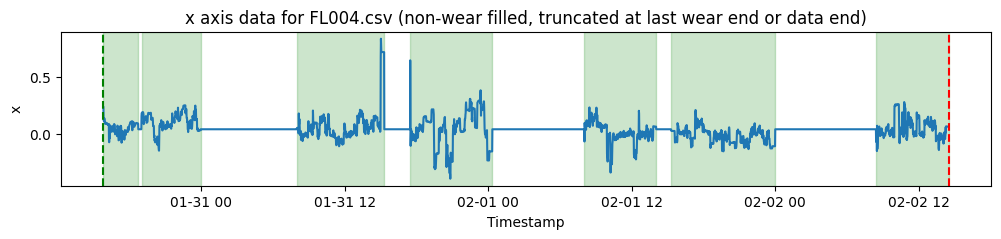

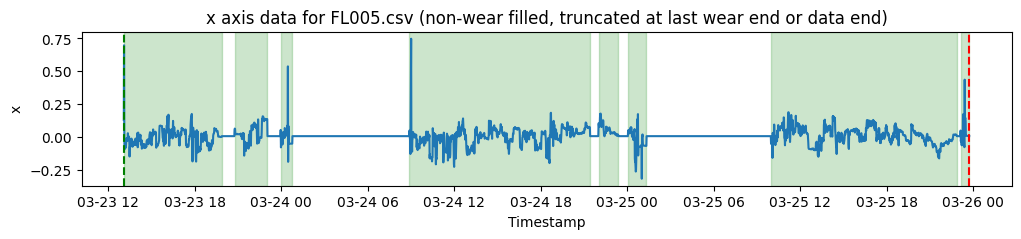

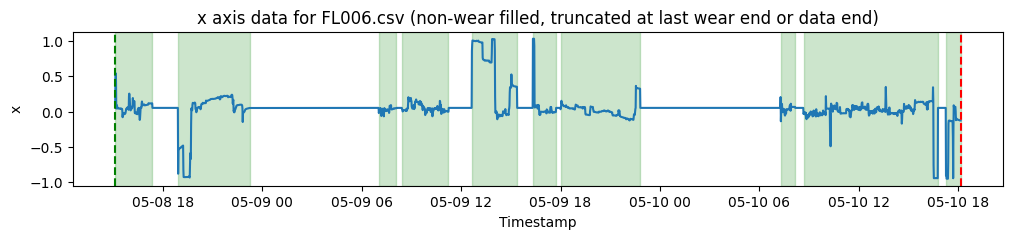

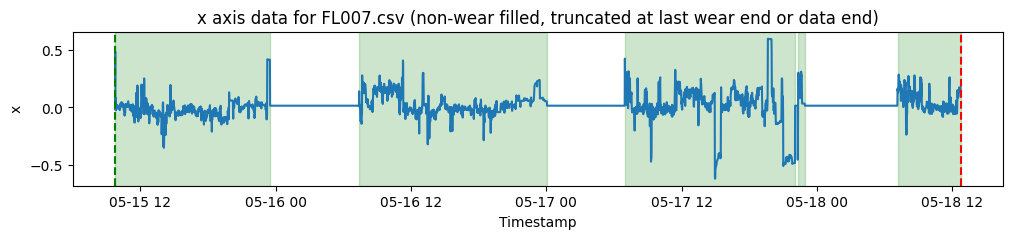

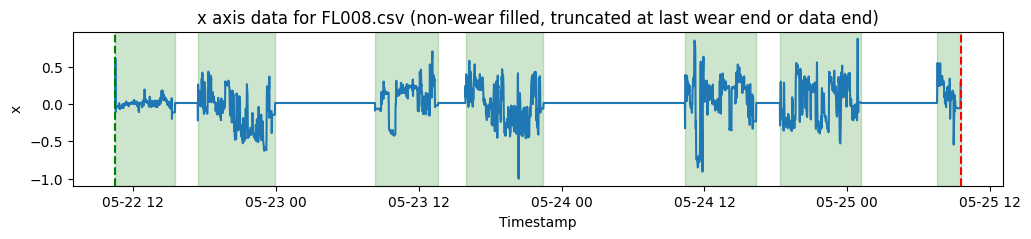

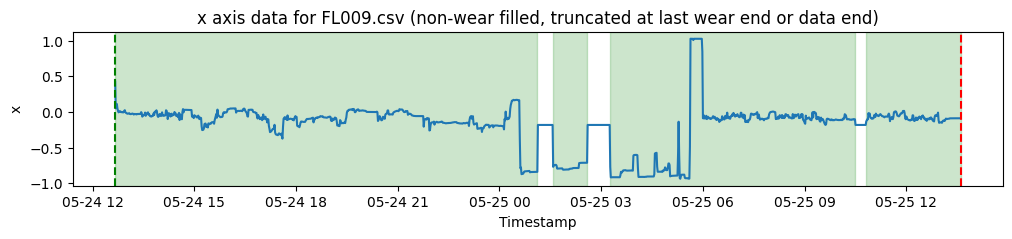

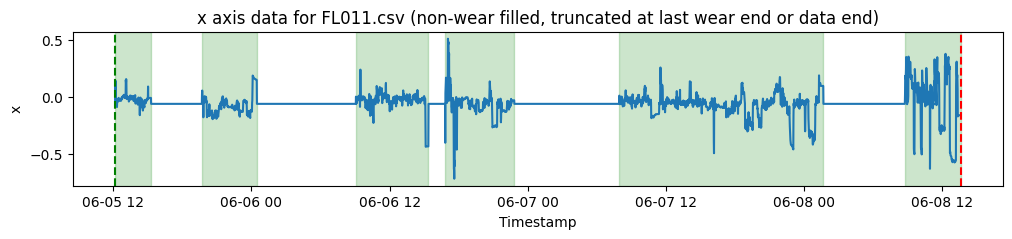

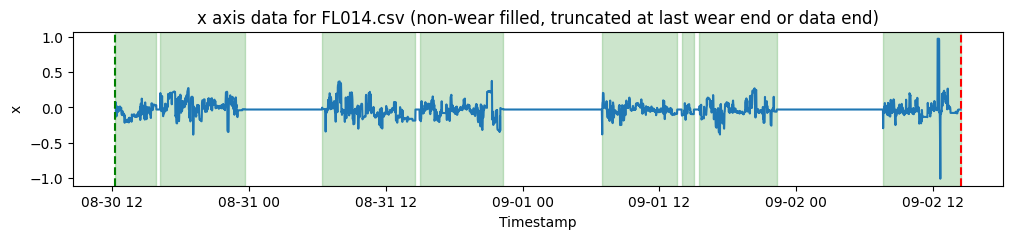

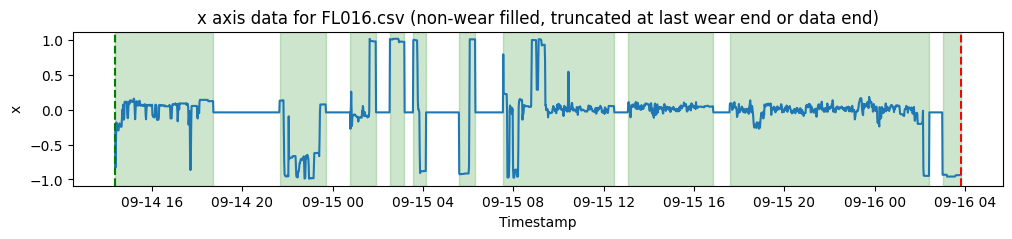

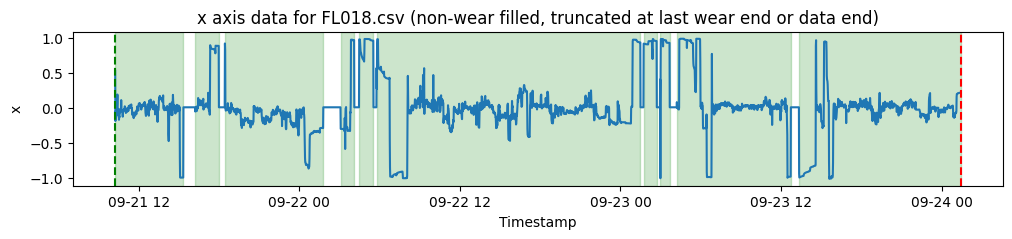

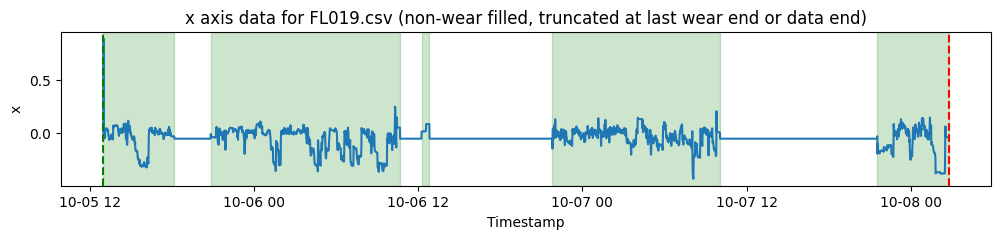

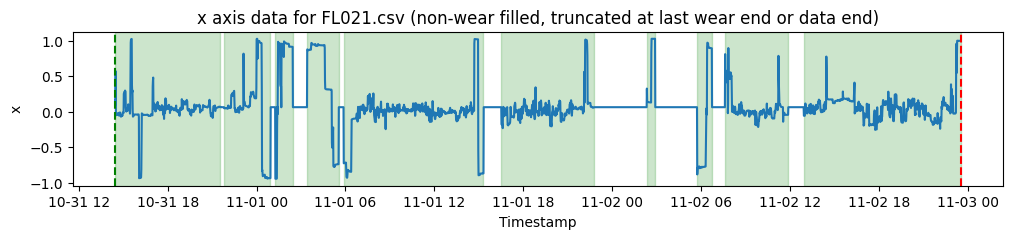

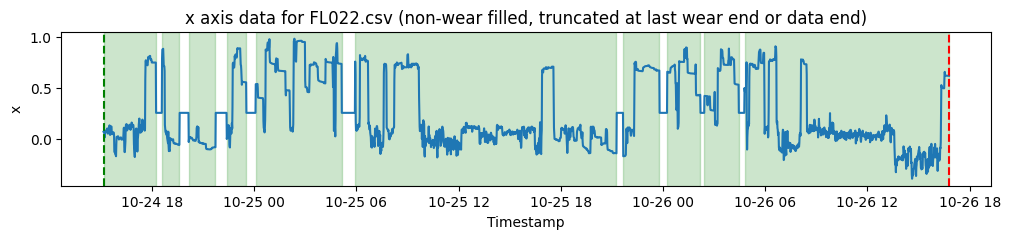

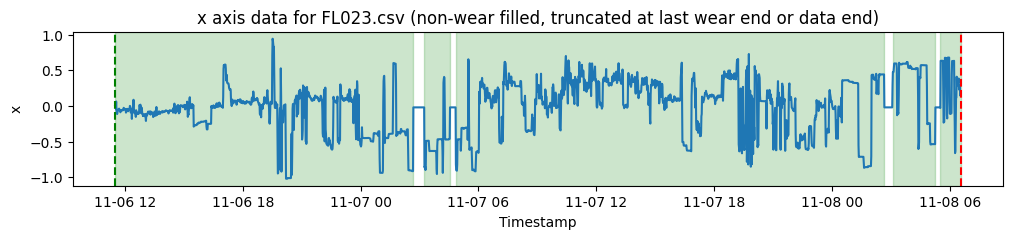

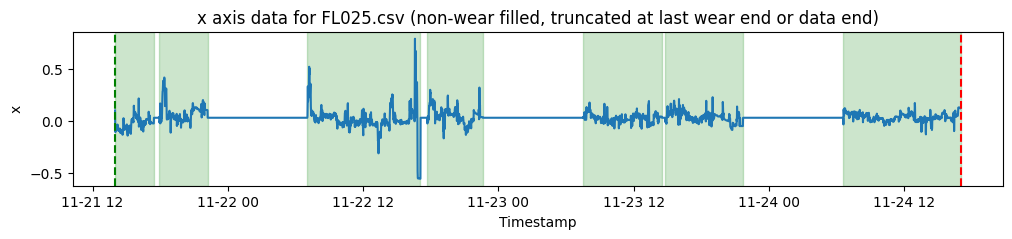

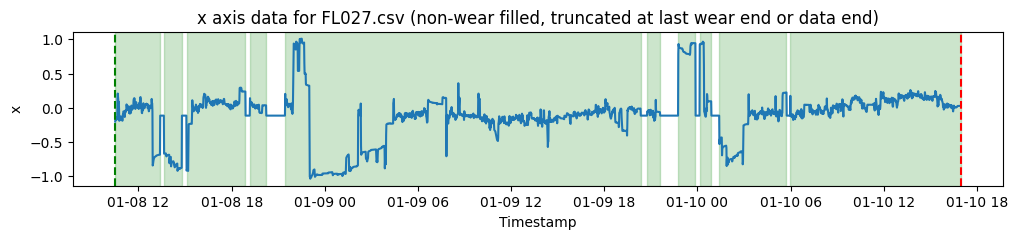

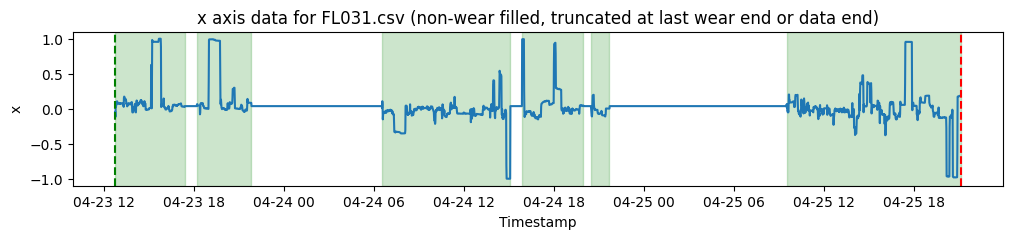

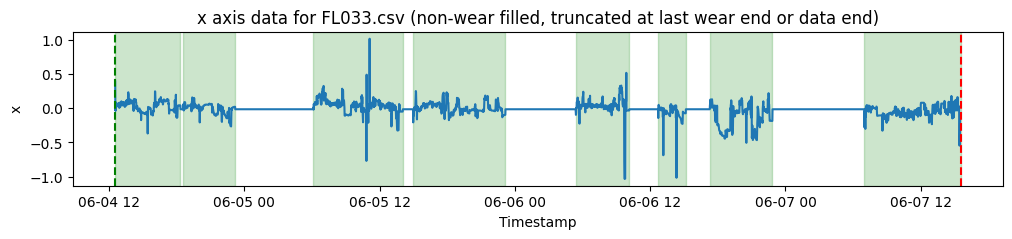

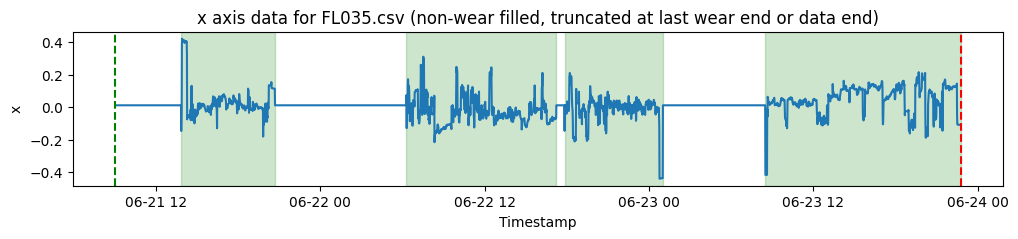

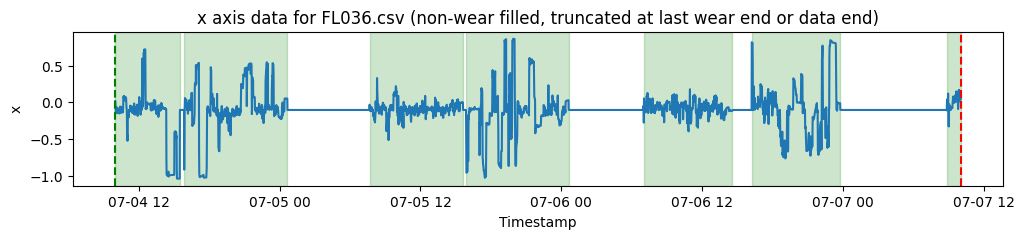

In [128]:
# For each pig_id in wear_df, try to find and plot the corresponding timeseries
for idx, row in wear_df.iterrows():
    pig_id = row['pig_id']
    # Accept both CO-001.csv and CO_001.csv, case-insensitive
    pig_id_pattern = pig_id.replace("-", "[-_]?")
    pattern = re.compile(rf"{pig_id_pattern}\.csv$", re.IGNORECASE)
    matching_files = [f for f in csv_files if pattern.search(os.path.basename(f))]
    if not matching_files:
        print(f"No file found for pig_id {pig_id}")
        continue
    csv_file = matching_files[0]
    df = pd.read_csv(csv_file)
    ts = pd.to_datetime(df['timestamp'])
    file_label = os.path.basename(csv_file)

    # Identify all wear periods and build a mask for wear
    wear_mask = pd.Series(False, index=df.index)
    wear_periods = []
    last_wear_end = None
    for i in range(1, 11):
        start_col = f'wear_start_{i}'
        end_col = f'wear_end_{i}'
        start = row[start_col] if pd.notna(row[start_col]) else ''
        end = row[end_col] if pd.notna(row[end_col]) else ''
        if start and end:
            start_dt = pd.to_datetime(start)
            end_dt = pd.to_datetime(end)
            # Mark as wear period
            mask = (ts >= start_dt) & (ts <= end_dt)
            wear_mask = wear_mask | mask
            wear_periods.append((start_dt, end_dt))
            if last_wear_end is None or end_dt > last_wear_end:
                last_wear_end = end_dt

    # Determine the cutoff for the end of the timeseries
    ts_end = ts.max()
    if last_wear_end is not None:
        cutoff = min(last_wear_end, ts_end)
    else:
        cutoff = ts_end

    # Only consider data up to the cutoff
    valid_mask = ts <= cutoff
    ts_valid = ts[valid_mask]
    df_valid = df.loc[valid_mask].copy()
    wear_mask_valid = wear_mask[valid_mask]

    # Compute the average value of 'x' during wear periods (within valid range)
    if wear_mask_valid.any():
        wear_mean = df_valid.loc[wear_mask_valid, 'x'].mean()
    else:
        wear_mean = df_valid['x'].mean()  # fallback if no wear periods

    # Fill non-wear periods with the average value of wear periods
    df_filled = df_valid.copy()
    df_filled.loc[~wear_mask_valid, 'x'] = wear_mean

    # --- Write the modified, truncated signals to new CSVs ---
    # Ensure output directory exists
    output_dir = "minute_level_modified"
    os.makedirs(output_dir, exist_ok=True)
    # Only keep timestamp, x, y, z columns (if present)
    cols_to_save = [col for col in ['timestamp', 'x', 'y', 'z'] if col in df_filled.columns]
    output_path = os.path.join(output_dir, file_label)
    df_filled[cols_to_save].to_csv(output_path, index=False)

    # --- Plotting (unchanged) ---
    plt.figure(figsize=(12, 2))
    plt.plot(ts_valid, df_filled['x'], label=f"{file_label} x (non-wear filled)")
    plt.axvline(ts_valid.min(), color='g', linestyle='--', label='Min timestamp')
    plt.axvline(ts_valid.max(), color='r', linestyle='--', label='Max timestamp')

    # Plot wear periods as green bands (only those within the cutoff)
    for start_dt, end_dt in wear_periods:
        span_start = max(start_dt, ts_valid.min())
        span_end = min(end_dt, cutoff)
        if span_start < span_end:
            plt.axvspan(span_start, span_end, color='green', alpha=0.2)

    plt.xlabel('Timestamp')
    plt.ylabel('x')
    plt.title(f'x axis data for {file_label} (non-wear filled, truncated at last wear end or data end)')
    plt.show()

In [129]:
modified_dir = "minute_level_modified"
data_handlers = []

preprocess_args = {}  # Define or update this as needed

for fname in os.listdir(modified_dir):
    try:
        file_path = os.path.join(modified_dir, fname)
        if os.path.isfile(file_path):
            handler = csa.datahandlers.GenericDataHandler(
                file_path=file_path,
                data_format='csv',
                data_type='accelerometer-g',
                time_format='datetime',
                time_column='timestamp',
                time_zone="UTC",
                data_columns=['x', 'y', 'z'],
                preprocess_args=preprocess_args,
                verbose=False
            )
            data_handlers.append(handler)
    except Exception as e:
        print(f"Error processing {fname}: {e}")

Error processing FL009.csv: Less than 1 day found
Error processing CO024.csv: Less than 1 day found


In [130]:
features_args = {}

bulk_features = csa.features.BulkWearableFeatures(
    handlers=data_handlers, 
    features_args=features_args,
    compute_distributions=True
    )

bulk_features.get_summary_dataframe()

,feature,count,mean,std,min,max,median,q25,q75,iqr,mode,skewness
0,cosinor_mesor,52,25.326295,19.116549,0.274038,84.662502,21.229415,9.848243,37.293061,27.444819,0.274038,0.720292
1,cosinor_amplitude,52,16.004335,14.444825,0.486384,81.851820,12.664317,5.417617,22.655534,17.237918,0.486384,2.126821
2,cosinor_acrophase,52,-3.011077,1.853083,-5.960865,-0.035495,-3.942384,-4.367876,-1.109265,3.258611,-5.960865,0.179729
3,cosinor_acrophase_time,52,690.088080,424.695247,8.134955,1366.129633,903.527909,254.224752,1001.043359,746.818607,8.134955,-0.179729
4,nonparam_IS,52,0.729742,0.290614,0.205300,1.000000,0.853643,0.415552,1.000000,0.584448,1.000000,-0.515073
5,nonparam_IV,52,0.710307,0.419398,0.143644,1.750179,0.674336,0.374540,0.964694,0.590154,0.143644,0.748827
6,nonparam_M10,52,38.011078,25.627668,0.657692,95.200145,34.432877,19.292164,53.819959,34.527795,0.657692,0.411072
7,nonparam_L5,52,6.018708,11.191104,0.000000,69.021432,0.311934,0.000000,8.719174,8.719174,0.000000,3.754904
8,nonparam_RA,52,0.825198,0.225351,0.159411,1.000000,0.982682,0.677148,1.000000,0.322852,1.000000,-1.223889
9,physical_activity_sedentary,52,673.134615,387.269610,64.000000,1382.000000,561.250000,370.750000,1014.125000,643.375000,64.000000,0.248821


In [131]:
bulk_features.get_feature_correlation_matrix()

,cosinor_mesor,cosinor_amplitude,cosinor_acrophase,cosinor_acrophase_time,nonparam_IS,nonparam_IV,nonparam_M10,nonparam_L5,nonparam_RA,physical_activity_sedentary,physical_activity_light,physical_activity_moderate,physical_activity_vigorous,sleep_TST,sleep_WASO,sleep_PTA,sleep_NWB,sleep_SOL,sleep_SRI
cosinor_mesor,1.000000,0.706266,0.026540,-0.026540,0.145929,-0.446710,0.964629,0.512401,-0.371631,-0.763794,-0.099053,-0.117573,0.767163,-0.747100,0.175168,-0.747101,-0.210986,0.301607,0.365676
cosinor_amplitude,0.706266,1.000000,0.155023,-0.155023,0.387464,-0.648193,0.829540,-0.073416,0.173847,-0.342697,-0.061528,0.037803,0.343354,-0.314077,-0.042357,-0.314079,-0.102446,0.112748,0.206832
cosinor_acrophase,0.026540,0.155023,1.000000,-1.000000,0.161405,-0.275904,0.076222,0.003504,-0.128995,-0.099740,0.416327,0.164269,0.097534,0.147618,0.240040,0.147616,0.421461,-0.204666,0.443551
cosinor_acrophase_time,-0.026540,-0.155023,-1.000000,1.000000,-0.161405,0.275904,-0.076222,-0.003504,0.128995,0.099740,-0.416327,-0.164269,-0.097534,-0.147618,-0.240040,-0.147616,-0.421461,0.204666,-0.443551
nonparam_IS,0.145929,0.387464,0.161405,-0.161405,1.000000,-0.134529,0.170870,-0.194892,0.264187,-0.107973,0.056073,0.165305,0.106517,-0.071837,0.111160,-0.071838,-0.189885,-0.124651,0.534137
nonparam_IV,-0.446710,-0.648193,-0.275904,0.275904,-0.134529,1.000000,-0.556157,0.024362,-0.039461,0.452702,-0.136303,-0.286942,-0.450794,0.352292,-0.216024,0.352293,-0.086212,-0.026340,-0.219407
nonparam_M10,0.964629,0.829540,0.076222,-0.076222,0.170870,-0.556157,1.000000,0.348443,-0.211012,-0.676551,-0.080312,-0.067102,0.679156,-0.640893,0.163657,-0.640894,-0.159943,0.264983,0.296867
nonparam_L5,0.512401,-0.073416,0.003504,-0.003504,-0.194892,0.024362,0.348443,1.000000,-0.926194,-0.709972,0.009227,-0.043909,0.712254,-0.609765,0.355065,-0.609766,-0.041220,0.106398,0.380697
nonparam_RA,-0.371631,0.173847,-0.128995,0.128995,0.264187,-0.039461,-0.211012,-0.926194,1.000000,0.702643,-0.179913,-0.100028,-0.703140,0.584868,-0.428425,0.584868,-0.170224,-0.107658,-0.406371
physical_activity_sedentary,-0.763794,-0.342697,-0.099740,0.099740,-0.107973,0.452702,-0.676551,-0.709972,0.702643,1.000000,-0.234804,-0.225182,-0.999937,0.899605,-0.527151,0.899606,0.004903,-0.212754,-0.553632
